# 06 — Making overfitting and UGM leakage visible

This notebook deliberately creates a problematic split. Complete UGM IDs are first reserved as
an unknown-UGM test. Remaining rows are then randomly divided without grouping, so the naive test
often contains UGMs also seen during training. A flexible model can recognize their signatures;
the unknown-UGM test reveals actual generalization. Ethanol makes the contrast especially clear.

## Software, experiment design, and parameters

This is intentionally a negative demonstration, not a valid baseline. `GAS`, the ALA segment
count, held-out UGM fraction, and random seed control it. `GroupShuffleSplit` first reserves
complete unknown UGM IDs; `train_test_split` then deliberately splits the remaining rows and
creates UGM leakage. Extra Trees varies from strongly smoothed to highly flexible through
`min_samples_leaf`. The figures contrast recognition of familiar UGMs with generalization to
entirely new mixtures.

In [1]:
# Ethanol makes the leakage/generalization difference especially clear.
GAS = "ethanol"
N_ALA_SEGMENTS = 50
HELD_OUT_UGM_FRACTION = 0.20
RANDOM_STATE_DEMO = 17

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupShuffleSplit, train_test_split

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import extract_ala_features, learn_ala_breakpoints

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>" for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Construct a naive test and an honest test

In [3]:
original = prepare_splits("stored")
X_all = np.concatenate([original[name]["X"] for name in SPLIT_NAMES])
y_all = np.concatenate([
    original[name]["targets"][GAS] for name in SPLIT_NAMES
]).astype(float)
ugm_all = np.concatenate([
    original[name]["targets"]["range"] for name in SPLIT_NAMES
]).astype(int)

# Keep the UGM 1–500 concentration region fixed for this demonstration.
base = ugm_all <= BASE_SEGMENT_MAX_UGM
X_all, y_all, ugm_all = X_all[base], y_all[base], ugm_all[base]
all_positions = np.arange(len(X_all))

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=HELD_OUT_UGM_FRACTION,
    random_state=RANDOM_STATE_DEMO,
)
development_pos, unseen_ugm_pos = next(
    group_splitter.split(X_all, y_all, groups=ugm_all)
)

# Deliberately row-wise: the same UGM IDs may occur in several splits.
train_val_pos, random_test_pos = train_test_split(
    development_pos, test_size=0.20, random_state=RANDOM_STATE_DEMO
)
train_pos, val_pos = train_test_split(
    train_val_pos, test_size=0.20, random_state=RANDOM_STATE_DEMO
)
positions = {
    "train": train_pos,
    "val": val_pos,
    "random_test": random_test_pos,
    "unseen_ugm_test": unseen_ugm_pos,
}

train_ugms = set(ugm_all[train_pos])
split_rows = []
for name, index in positions.items():
    groups = set(ugm_all[index])
    overlap = len(groups & train_ugms)
    split_rows.append({
        "Split": name,
        "Rows": len(index),
        "UGM IDs": len(groups),
        "UGM overlap with training": overlap,
        "Rows with training UGM [%]":
            100 * np.mean(np.isin(ugm_all[index], list(train_ugms))),
    })
show_table(split_rows, list(split_rows[0]), digits=1)

Split,Rows,UGM IDs,UGM overlap with training,Rows with training UGM [%]
train,869,380,380,100.0
val,218,191,177,90.4
random_test,272,213,195,87.5
unseen_ugm_test,343,100,0,0.0


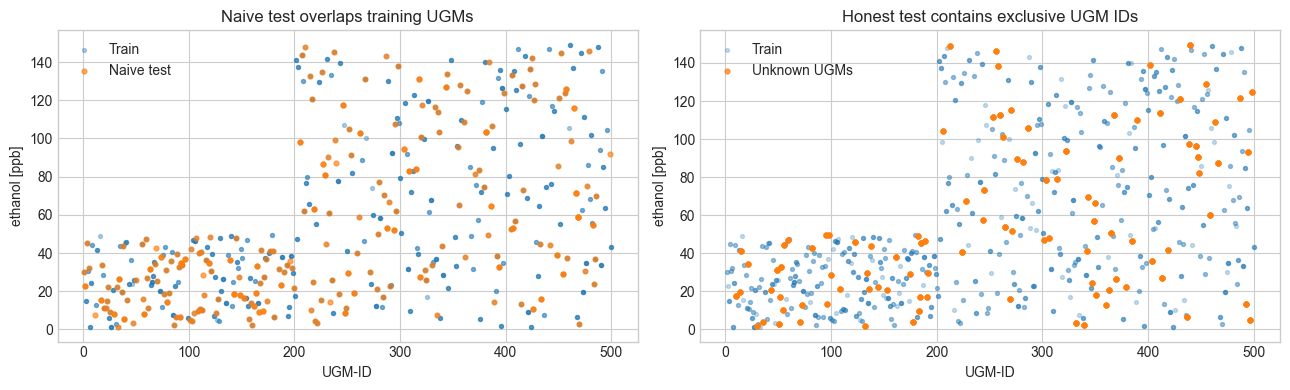

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(ugm_all[train_pos], y_all[train_pos], s=8, alpha=0.35,
                label="Train")
axes[0].scatter(ugm_all[random_test_pos], y_all[random_test_pos],
                s=12, alpha=0.65, label="Naive test")
axes[0].set(xlabel="UGM-ID", ylabel=f"{GAS} [ppb]",
            title="Naive test overlaps training UGMs")
axes[0].legend()

axes[1].scatter(ugm_all[train_pos], y_all[train_pos], s=8, alpha=0.25,
                label="Train")
axes[1].scatter(ugm_all[unseen_ugm_pos], y_all[unseen_ugm_pos],
                s=12, alpha=0.75, label="Unknown UGMs")
axes[1].set(xlabel="UGM-ID", ylabel=f"{GAS} [ppb]",
            title="Honest test contains exclusive UGM IDs")
axes[1].legend()
plt.tight_layout()
plt.show()

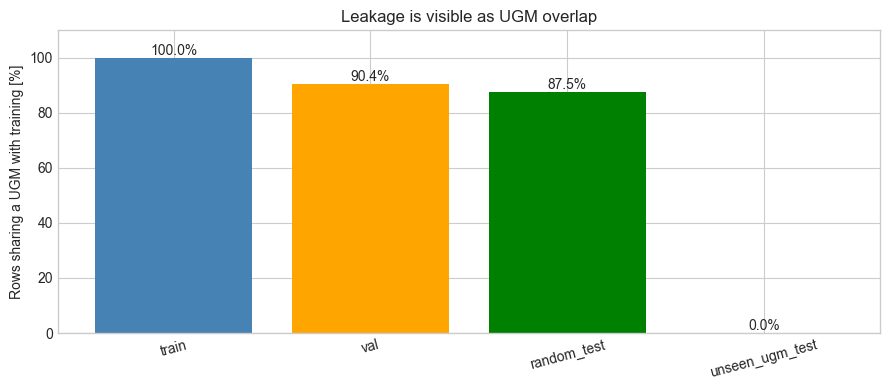

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
names = [row["Split"] for row in split_rows]
overlap = [row["Rows with training UGM [%]"] for row in split_rows]
bars = ax.bar(names, overlap, color=["steelblue", "orange", "green", "red"])
ax.bar_label(bars, fmt="%.1f%%")
ax.set(
    ylabel="Rows sharing a UGM with training [%]",
    title="Leakage is visible as UGM overlap",
    ylim=(0, 110),
)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()

## 2. Same features and model—the test definition is the only difference

Fifty ALA segments provide means and slopes. Boundaries are learned from the training median only.
Extra Trees is intentionally flexible so recognition and generalization separate visibly.

In [6]:
train_reference = np.median(X_all[train_pos, 0, :], axis=0)
breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)
X_features, feature_names = extract_ala_features(X_all, breakpoints)
print("ALA features:", X_features.shape[1])
print("Segment boundaries learned from training only:", len(breakpoints))

def regression_metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "R2": 1 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=RANDOM_STATE_DEMO,
    n_jobs=-1,
)
model.fit(X_features[train_pos], y_all[train_pos])

predictions = {
    name: model.predict(X_features[index])
    for name, index in positions.items()
}
metric_rows = []
for name, index in positions.items():
    metric_rows.append({
        "Split": name,
        **regression_metrics(y_all[index], predictions[name]),
    })
show_table(metric_rows, ["Split", "R2", "MSE", "RMSE", "MAE"])

ALA features: 100
Segment boundaries learned from training only: 51


Split,R2,MSE,RMSE,MAE
train,1.000,0.000,0.000,0.000
val,0.688,559.378,23.651,17.291
random_test,0.694,510.273,22.589,17.123
unseen_ugm_test,0.228,1289.020,35.903,28.918


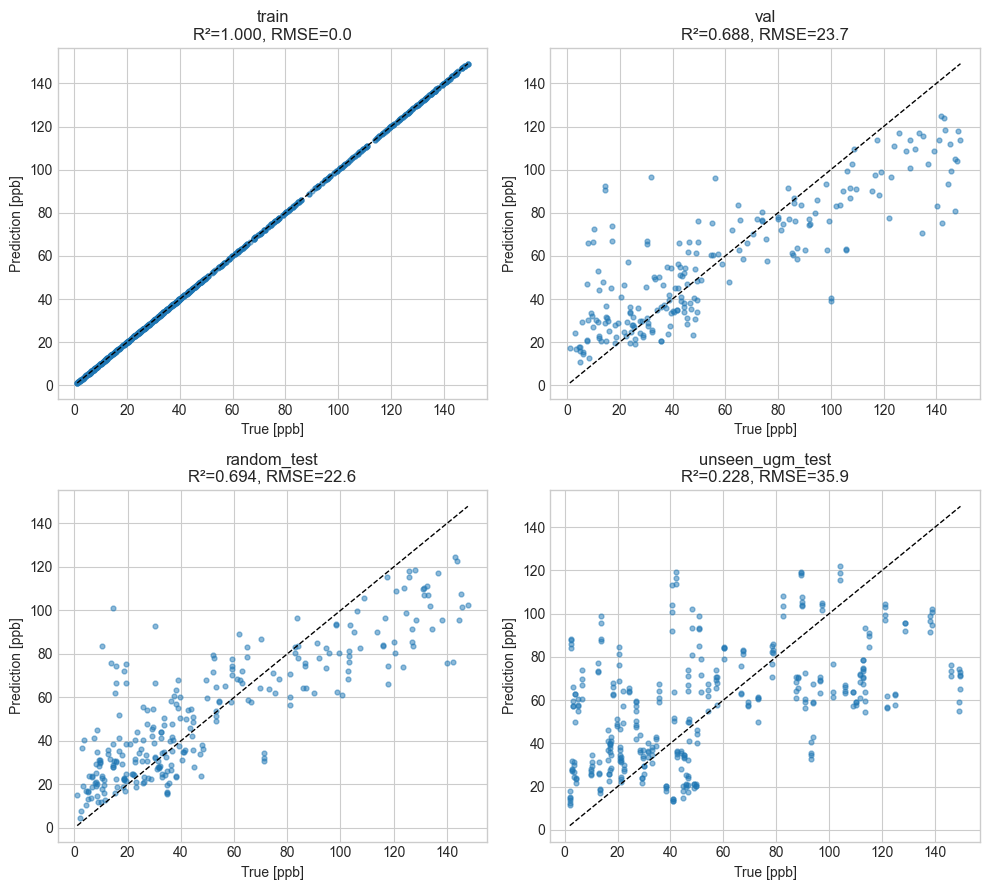

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, index) in zip(axes.flat, positions.items()):
    truth = y_all[index]
    prediction = predictions[name]
    lower = min(float(truth.min()), float(prediction.min()))
    upper = max(float(truth.max()), float(prediction.max()))
    score = regression_metrics(truth, prediction)
    ax.scatter(truth, prediction, s=12, alpha=0.5)
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
    ax.set(
        xlabel="True [ppb]", ylabel="Prediction [ppb]",
        title=f"{name}\nR²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}",
    )
plt.tight_layout()
plt.show()

## 3. Overfitting along a clearly ordered complexity axis

Complexity step,min_samples_leaf,Interpretation,R2 train,R2 random_test,R2 unseen_ugm_test
1,32,simple / strongly smoothed,0.471,0.404,0.284
2,16,simple / strongly smoothed,0.618,0.477,0.268
3,8,medium,0.797,0.568,0.252
4,4,medium,0.946,0.643,0.227
5,2,flexible / many small leaves,0.996,0.671,0.222
6,1,flexible / many small leaves,1.000,0.691,0.224


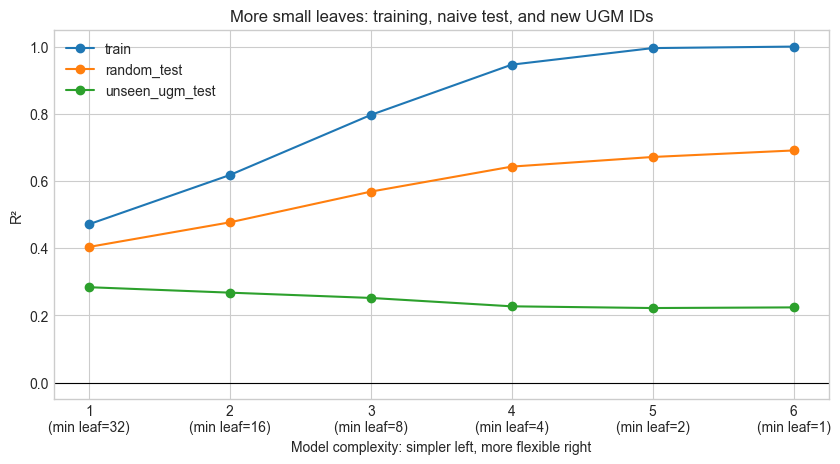

In [8]:
# min_samples_leaf is NOT the number of leaves.
# Large values force a few large leaves and a simple model.
# Small values allow many small leaves and a flexible model.
leaf_sizes = [32, 16, 8, 4, 2, 1]
complexity_rows = []
for complexity_step, leaf_size in enumerate(leaf_sizes, start=1):
    candidate = ExtraTreesRegressor(
        n_estimators=200,
        min_samples_leaf=leaf_size,
        max_features=1.0,
        random_state=RANDOM_STATE_DEMO,
        n_jobs=-1,
    )
    candidate.fit(X_features[train_pos], y_all[train_pos])
    row = {
        "Complexity step": complexity_step,
        "min_samples_leaf": leaf_size,
        "Interpretation": (
            "simple / strongly smoothed" if leaf_size >= 16
            else "medium" if leaf_size >= 4
            else "flexible / many small leaves"
        ),
    }
    for name in ("train", "random_test", "unseen_ugm_test"):
        index = positions[name]
        prediction = candidate.predict(X_features[index])
        row[f"R2 {name}"] = regression_metrics(y_all[index], prediction)["R2"]
    complexity_rows.append(row)

show_table(complexity_rows, list(complexity_rows[0]))

fig, ax = plt.subplots(figsize=(10, 4.8))
complexity_steps = [row["Complexity step"] for row in complexity_rows]
for split in ("train", "random_test", "unseen_ugm_test"):
    ax.plot(
        complexity_steps,
        [row[f"R2 {split}"] for row in complexity_rows],
        marker="o",
        label=split,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(complexity_steps)
ax.set_xticklabels([
    f"{step}\n(min leaf={leaf_size})"
    for step, leaf_size in zip(complexity_steps, leaf_sizes)
])
ax.set(
    xlabel="Model complexity: simpler left, more flexible right",
    ylabel="R²",
    title="More small leaves: training, naive test, and new UGM IDs",
)
ax.legend()
plt.show()

## What counts as overfitting here?

`min_samples_leaf` is not the number of leaves. A value of 32 forces large, smooth leaves;
a value of 1 permits many small leaves and a flexible model. Moving left to right therefore
increases complexity. Rising training performance combined with declining unknown-UGM performance
after an optimum is the generalization gap. If a smooth model is poor everywhere, that is
underfitting. The random test is not proof of generalization because it shares UGM situations
with training. Only `unseen_ugm_test` answers whether the model handles entirely new mixtures.
This notebook is a negative demonstration; grouped splits remain authoritative.